In [3]:
import pandas as pd

df = pd.read_csv("housing.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

Shape: (20640, 10)

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Basic statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing values in % :")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing values in % :
longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64


In [5]:
# Fill missing total_bedrooms with the median
median_bedrooms = df["total_bedrooms"].median()
print(median_bedrooms)
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

# Confirm no more missing values
print("Missing values after fix:")
print(df.isnull().sum())

435.0
Missing values after fix:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [6]:
# Create more meaningful ratio-based features
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

print("New columns added:")
print(df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe())

New columns added:
       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20640.000000              20640.000000
mean              5.429000           0.213794                  3.070655
std               2.474173           0.065248                 10.386050
min               0.846154           0.037151                  0.692308
25%               4.440716           0.175225                  2.429741
50%               5.229129           0.203159                  2.818116
75%               6.052381           0.240126                  3.282261
max             141.909091           2.824675               1243.333333


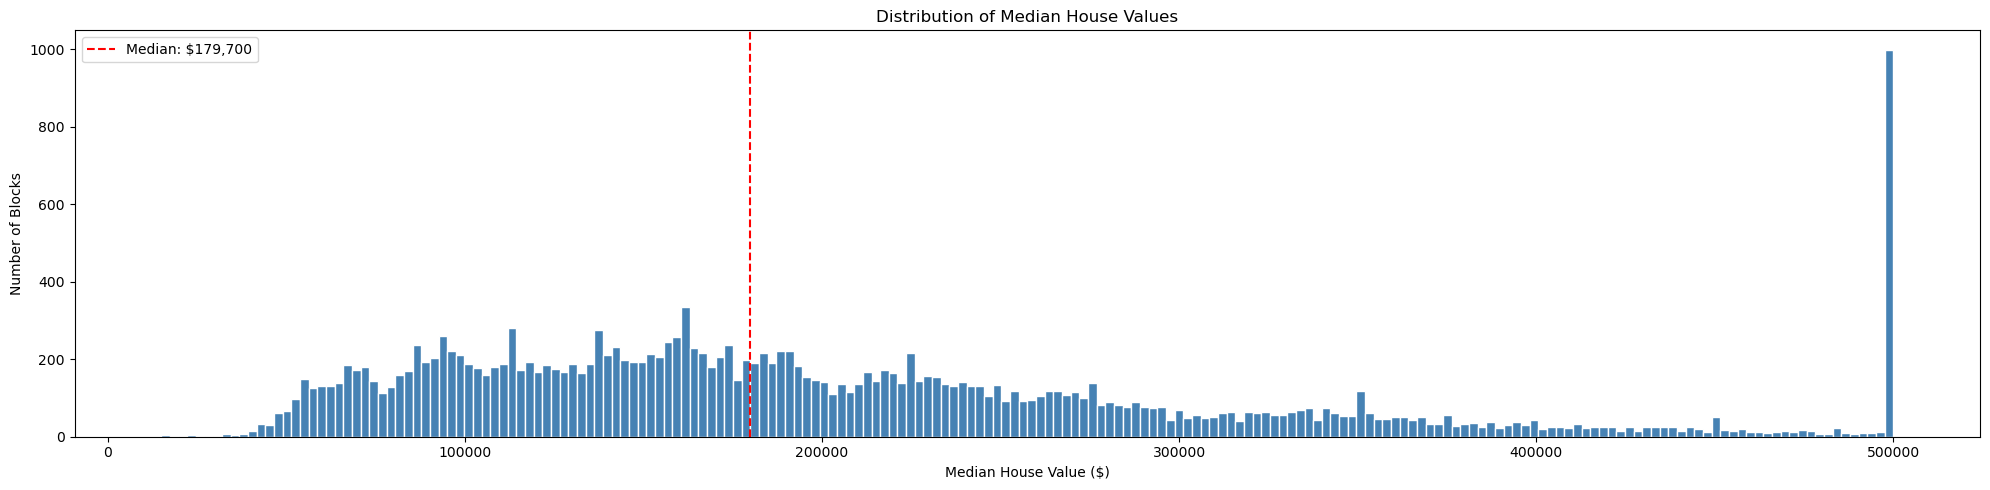

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
plt.hist(df["median_house_value"], bins=200, color="steelblue", edgecolor="white")
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value ($)")
plt.ylabel("Number of Blocks")
plt.axvline(df["median_house_value"].median(), color="red", linestyle="--", label=f'Median: ${df["median_house_value"].median():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Fördelningen är ungefär högersned — de flesta kvarter har husvärden mellan 50 000 och 300 000 dollar, med medianen på 179 700 dollar.
# Det finns en tydlig artificiell topp vid 500 001 dollar — detta är ett maxvärde eller tak, vilket innebär att alla värden över 500 000 dollar registrerades som 500 001 dollar.
# Detta kommer att påverka alla modeller som tränats på dessa data och bör noteras.

<Figure size 2000x500 with 0 Axes>

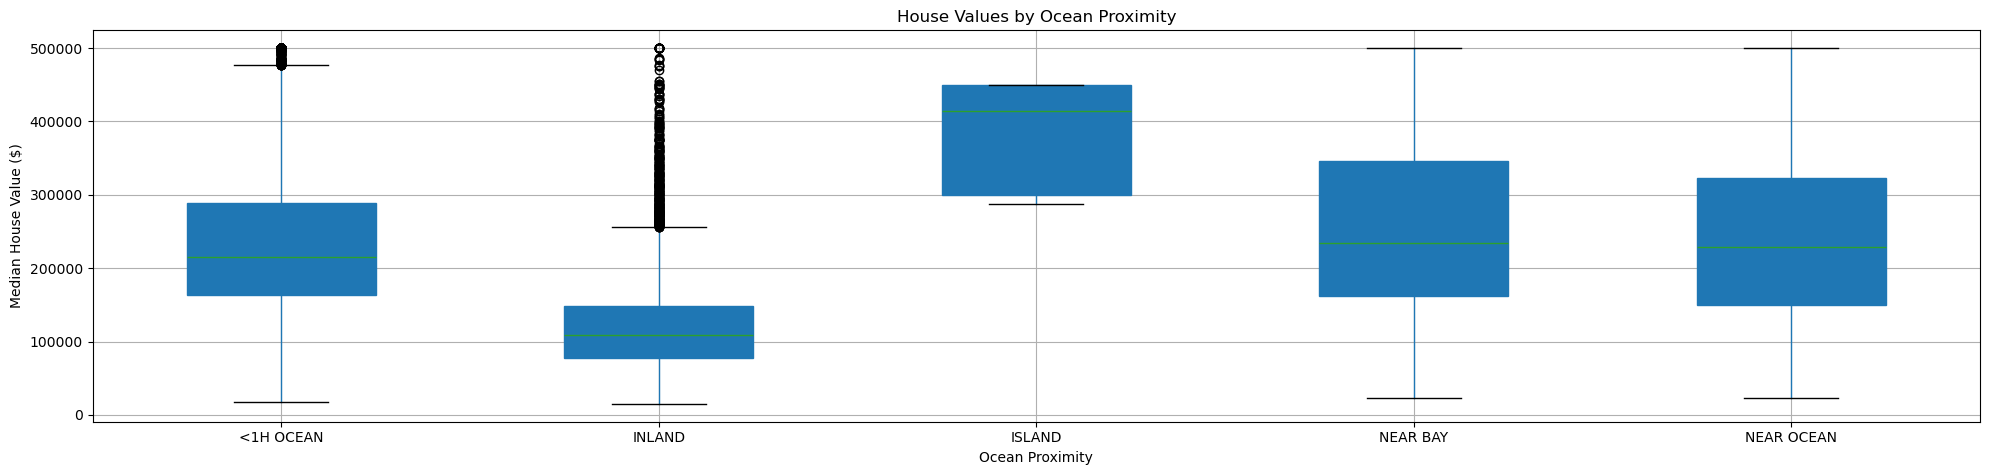

ocean_proximity
ISLAND        380440.0
NEAR BAY      259212.0
NEAR OCEAN    249434.0
<1H OCEAN     240084.0
INLAND        124805.0
Name: median_house_value, dtype: float64


In [8]:
plt.figure(figsize=(20, 5))
df.boxplot(column="median_house_value", by="ocean_proximity", 
           patch_artist=True, figsize=(20,5))
plt.title("House Values by Ocean Proximity")
plt.suptitle("")  # removes default pandas subtitle
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value ($)")
plt.tight_layout()
plt.show()

# Also print the mean per category
print(df.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False).round(0))

In [ ]:
# Fastigheter på öar är överlägset dyrast (median ~400 000 USD+) men representerar väldigt få datapunkter – inte statistiskt representativa.
# Inland är den billigaste kategorin med en median på runt 110 000 USD.
# <1H OCEAN, NEAR BAY och NEAR OCEAN är grupperade på liknande sätt runt 200 000–240 000 USD.
# Viktig insikt: närhet till havet ökar husvärdet avsevärt,
# där Inland är ungefär hälften så dyrt som kustkategorier.
# Inland har också många extremvärden (punkter ovanför morrhåret) – vissa kvarter på inlandet är förvånansvärt dyra trots att kategorigenomsnittet är lågt.

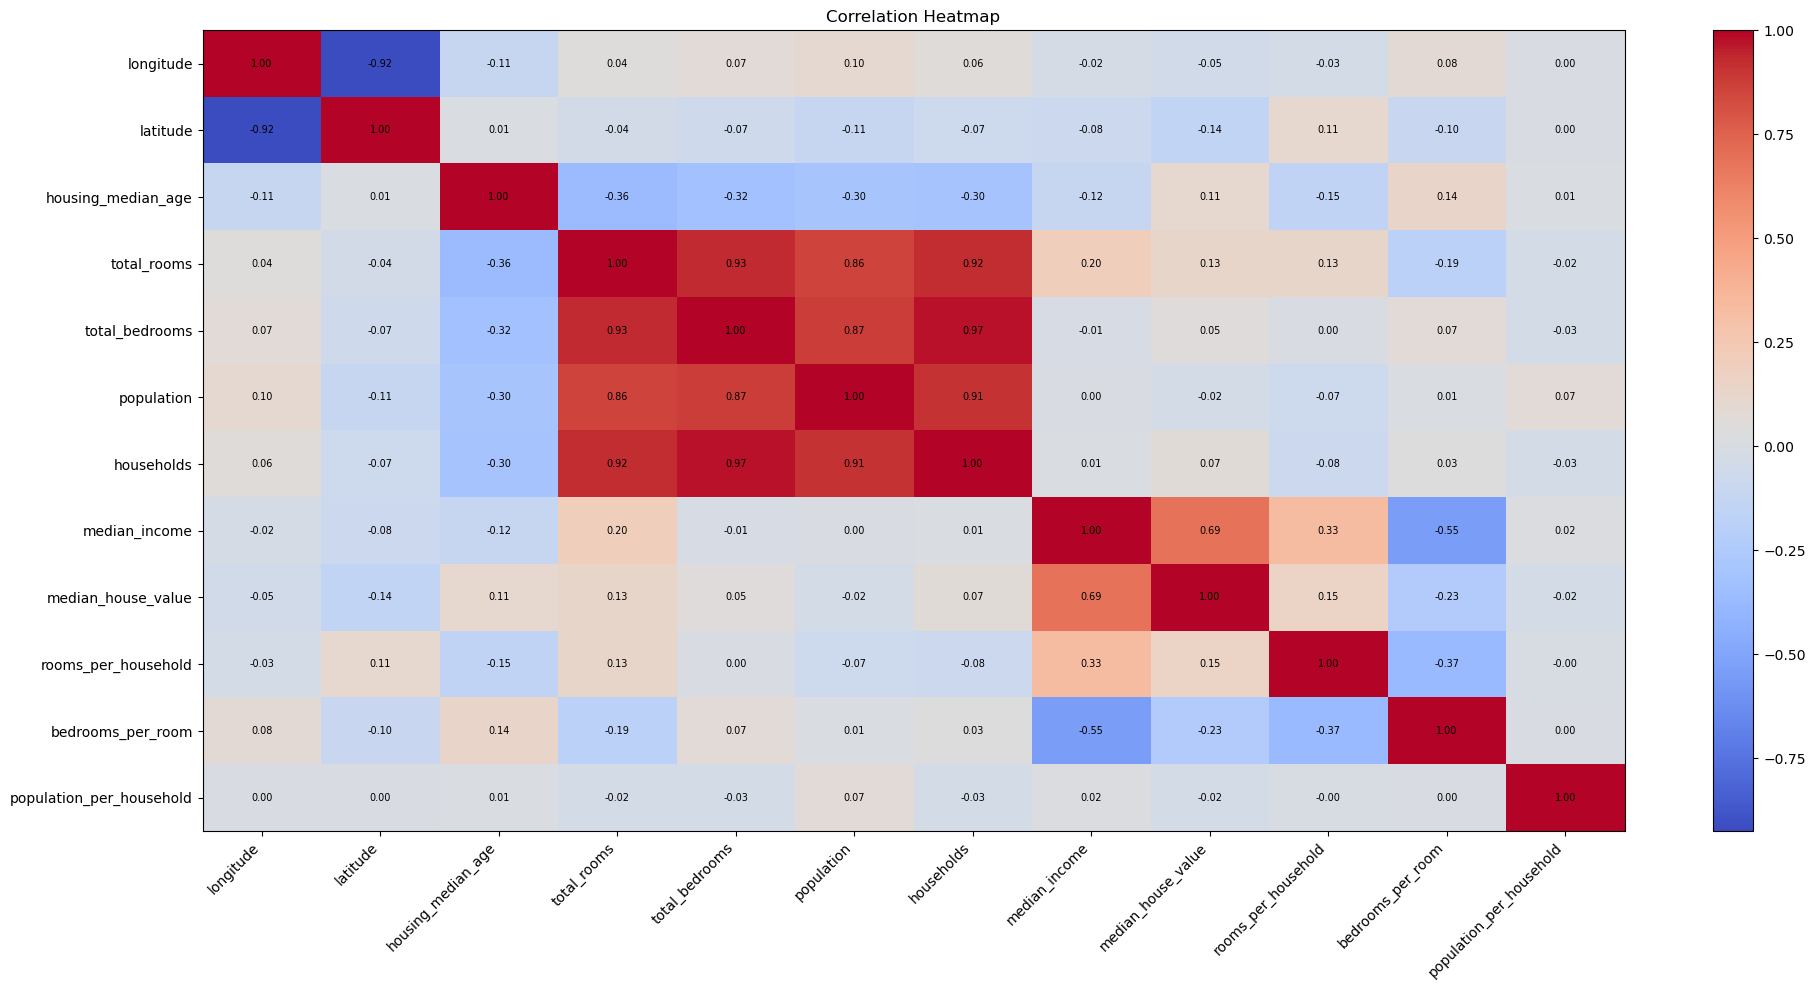

Correlations with median_house_value:
median_house_value          1.000
median_income               0.688
rooms_per_household         0.152
total_rooms                 0.134
housing_median_age          0.106
households                  0.066
total_bedrooms              0.049
population_per_household   -0.024
population                 -0.025
longitude                  -0.046
latitude                   -0.144
bedrooms_per_room          -0.233
Name: median_house_value, dtype: float64


In [10]:
import numpy as np

plt.figure(figsize=(20, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

im = plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")

# Add correlation values inside the cells
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", 
                ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

# Print top correlations with house value
print("Correlations with median_house_value:")
print(correlation["median_house_value"].sort_values(ascending=False).round(3))

In [ ]:
# KEY FINDINGS from correlation heatmap:
#
# 1. medianinkomst har den starkaste korrelationen med medianhusvärde (0,69)
# — den enskilt viktigaste prediktorn för huspris.
#
# 2. sovrum_per_rum har en NEGATIV korrelation (-0,23) med husvärdet
# — kvarter med en högre sovrumsandel tenderar att vara billigare (tätare, mindre rymliga bostäder).
# Detta bekräftar att vår konstruerade funktion är meningsfull.
#
# 3. totalt_rum, totalt_sovrum, befolkning, hushåll är alla starkt korrelerade
# med VARANDRA (0,86–0,97) — de mäter samma sak (kvarterstorlek).
# Att använda alla i en modell skulle orsaka multikollinearitet.
#
# 4. rum_per_hushåll har en blygsam positiv korrelation (0,15) med husvärdet
# — rymligare bostäder kostar mer, som förväntat.
#
# 5. housing_median_age har nästan ingen korrelation med pris (0,11)
# — husets ålder ensamt förklarar inte priset särskilt mycket.

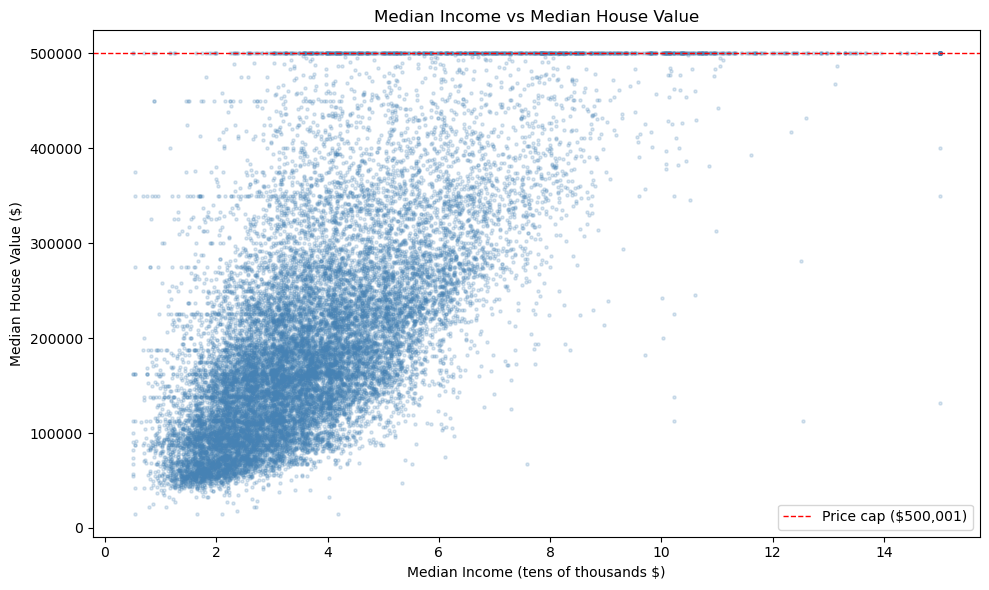

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df["median_income"], df["median_house_value"], 
            alpha=0.2, color="steelblue", s=5)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income (tens of thousands $)")
plt.ylabel("Median House Value ($)")
plt.axhline(500001, color="red", linestyle="--", linewidth=1, label="Price cap ($500,001)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Spridningsdiagrammet bekräftar att medianinkomsten är den starkaste prediktorn för husvärde (r=0,69).
# En tydlig uppåtgående trend är synlig – i takt med att grannskapets inkomster ökar,stiger husvärdena konsekvent.

# Den skarpa horisontella linjen vid 500 001 dollar bekräftar datataket som identifierades tidigare.
# Det finns också en synlig horisontell linje runt 350 000 dollar – ytterligare ett artificiellt
# tak i datamängden, vilket tyder på att datainsamlingen begränsades till flera prispunkter.
#
# Spridningen (variansen) ökar vid högre inkomster – dyrare områden har mer
# oförutsägbara priser, medan billigare områden är mer enhetliga och klustrade.
#
# Obs: medianinkomsten är i tiotusentals, så ett värde på 8 = 80 000 dollar/år.
# De flesta hushåll är klustrade mellan inkomst 1–6 (10 000–60 000 dollar/år),
# med väldigt få block som överstiger inkomst 10 (100 000 dollar/år).

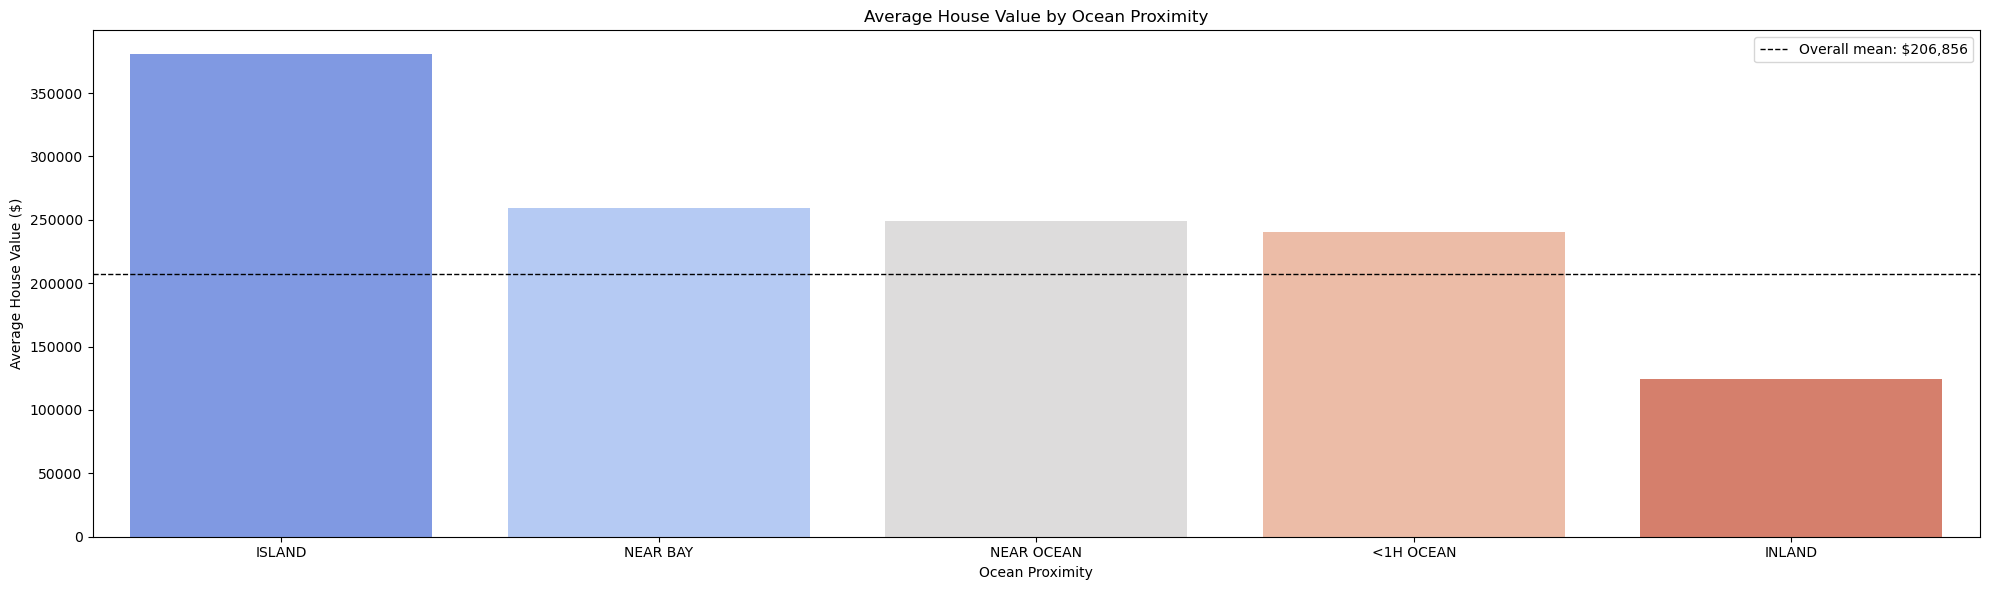

In [17]:
import seaborn as sns

plt.figure(figsize=(20, 6))
ocean_avg = df.groupby("ocean_proximity")["median_house_value"].mean().reset_index()
ocean_avg = ocean_avg.sort_values("median_house_value", ascending=False)

sns.barplot(data=ocean_avg, 
            x="ocean_proximity", 
            y="median_house_value",
            hue="ocean_proximity",
            palette="coolwarm",
            legend=False)

plt.title("Average House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Average House Value ($)")
plt.axhline(df["median_house_value"].mean(), color="black", 
            linestyle="--", linewidth=1, label=f'Overall mean: ${df["median_house_value"].mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Seaborn-barplotten visar tydligt prishierarkin efter närhet till havet.
# ISLAND är dyrast. NEAR BAY och NEAR OCEAN ligger långt över medelvärdet på 206 856 dollar och <1H OCEAN ligger strax ovanför medelvärdet./
# INLAND ligger dramatiskt under medelvärdet på ~125 000 dollar – ungefär hälften av det totala genomsnittet, vilket bekräftar att det är den mest prisvärda bostadskategorin.


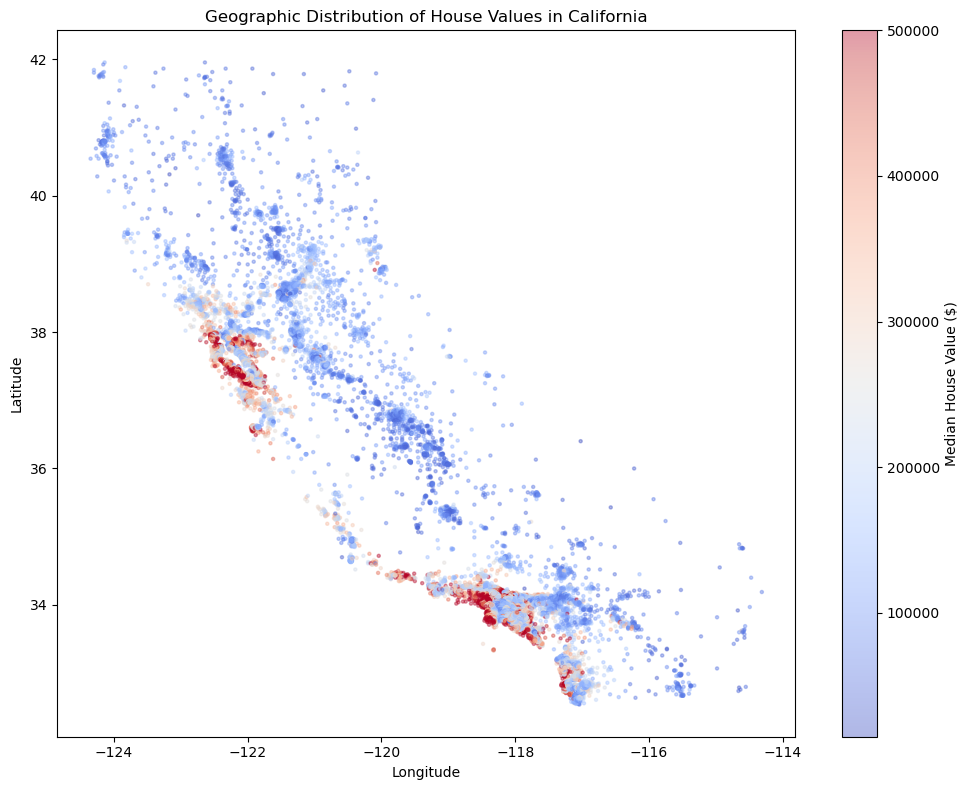

In [14]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df["longitude"], df["latitude"],
                      c=df["median_house_value"],
                      cmap="coolwarm",
                      alpha=0.4, s=5)
plt.colorbar(scatter, label="Median House Value ($)")
plt.title("Geographic Distribution of House Values in California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [15]:
print("TOP 5 MOST EXPENSIVE DISTRICTS:")
print(df.nlargest(5, "median_house_value")[
    ["median_house_value", "median_income", "ocean_proximity", "housing_median_age"]
])

print("\nTOP 5 CHEAPEST DISTRICTS:")
print(df.nsmallest(5, "median_house_value")[
    ["median_house_value", "median_income", "ocean_proximity", "housing_median_age"]
])

print("\nAVERAGE HOUSE VALUE BY OCEAN PROXIMITY:")
print(df.groupby("ocean_proximity")["median_house_value"]
    .agg(["mean", "median", "count"])
    .round(0)
    .sort_values("mean", ascending=False))

TOP 5 MOST EXPENSIVE DISTRICTS:
     median_house_value  median_income ocean_proximity  housing_median_age
89             500001.0         1.2434        NEAR BAY                52.0
459            500001.0         1.1696        NEAR BAY                52.0
493            500001.0         7.8521        NEAR BAY                52.0
494            500001.0         9.3959        NEAR BAY                52.0
509            500001.0         7.8772        NEAR BAY                52.0

TOP 5 CHEAPEST DISTRICTS:
       median_house_value  median_income ocean_proximity  housing_median_age
2521              14999.0         1.6607          INLAND                16.0
2799              14999.0         2.1000          INLAND                19.0
9188              14999.0         4.1932          INLAND                52.0
19802             14999.0         0.5360          INLAND                36.0
5887              17500.0         2.3667       <1H OCEAN                39.0

AVERAGE HOUSE VALUE BY OCEAN

In [ ]:
# SLUTGILTIGA SAMMANFATTNINGSRAPPORTER:
#
#  Dyraste distrikt (alla $500 001 = datatak):
# — Alla i NEAR BAY, medianålder för bostäder 52 (äldst i datamängden)
# — Udda: vissa har mycket låg medianinkomst (1,24, 1,17) men når ändå taket
# — Priset här verkar styras av läge/prestige, inte vad invånarna tjänar
#
# Billigaste distrikt (alla ~$15 000):
# — Alla I INLANDET — i linje med mönstret för närhet till havet
# — Åldrar och inkomster varierar mycket, så billighet handlar inte specifikt om gammalt boskap eller fattigdom
#  Det är bara: i inlandet. 
# Genomsnittligt husvärde efter närhet till havet:
# 1. Ö: 380 440 USD i genomsnitt (endast 5 kvarter — ignorera detta)
# 2. NÄRA VIKTEN: 259 212 USD i genomsnitt (2 290 kvarter)
# 3. NÄRA HAVET: 249 434 USD i genomsnitt (2 658 kvarter)
# 4. <1H HAVET: 240 084 USD i genomsnitt (9 136 kvarter — största kustgruppen)
# 5. INLANDET: 124 805 USD i genomsnitt (6 551 kvarter)
#
# INLANDET är ungefär hälften så dyrt som NÄRA VIKTEN (52 % billigare).
# De tre kustkategorierna ligger förvånansvärt nära varandra.